# Event Data March 2024 Analysis
## Liaohan Wang

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import json
import networkx as nx
import re
from prettytable import PrettyTable

In [3]:
event_data = pd.read_parquet('event_data_march_2024.parquet') 
event_data

,news_lang,source_id,ingest_project_code,news_type,news_publish_time,news_id,event_id,event_participant_id,event_participant_role,event_is_negated,amount,factuality,time,timex_start,timex_end,timex_anchor
0,en,5535,default,non_professional,1709739009,dc0c30fc2da26726f3d443671565ac6f3987f195,E41_A,stock_index:s_p_500,1,0,NaN,0,1,NaN,NaN,1.709683e+09
1,en,5535,default,non_professional,1710273735,d6edf09a97b3cd94629e9d53316591e84da88d9f,E41_A,stock_index:s_p_500,1,0,NaN,0,0,NaN,NaN,1.710202e+09
2,en,5535,default,non_professional,1710966029,b51b46b0feacf0d72a7444b93c9a1d961a207fce,E41_A,stock_index:s_p_500,1,0,NaN,0,1,NaN,NaN,1.710893e+09
3,en,5485,opoint,non_professional,1709307984,062e7380c7cba22b2a9a7a9290eb3763d95a1c39,E6_C,pne:company.advisor-group-holdings-inc,1,0,219.8,0,0,1.696118e+09,1.703981e+09,1.709251e+09
4,en,5485,opoint,non_professional,1709321449,41aafe11b78a5a0aba4039c9952868f37c6169bc,E6_C,pne:company.advisor-group-holdings-inc,1,0,1.5,0,0,1.696118e+09,1.703981e+09,1.709251e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24852045,en,20931,acquiremedia,non_professional,1710820800,68859151290380fbc939fabd1b62bd372e38ab41,E6_C,pne:company.product-line-development,1,0,24000.0,0,1,1.710374e+09,1.710374e+09,1.710806e+09
24852046,fr,5228,acquiremedia,non_professional,1710075600,8944f5281369989416440ae68dd486433d816c8a,E6_C,pne:company.producteur,2,0,NaN,7,4,NaN,NaN,NaN
24852047,fr,5228,acquiremedia,non_professional,1710669660,069a0e0968dbab9446265791e5e992c65be521e9,E6_C,pne:company.producteur,2,0,NaN,7,4,NaN,NaN,NaN
24852048,fr,1253841,opoint,non_professional,1710669714,65f84ab22b3f16700a2130e11d72ee344c80ea01,E6_C,pne:company.producteur,2,0,NaN,7,4,NaN,NaN,NaN


# Reformat Data
convert 'news_publish_time' 
<br> restore names for 'event_id' and 'factuality'
<br> drop 'event_is_negated', 'timex_start', 'timex_end', 'timex_anchor'
<br> change column names for 'time', 'eventDescription'
<br> change 'event_participant_id' empty values to NA

In [4]:
# drop columns
event_data = event_data.drop(columns=['source_id', 'ingest_project_code', 'event_is_negated', 'news_id', 'timex_start', 'timex_end', 'timex_anchor'])
# rename 
event_data = event_data.rename(columns={'time' : 'temporality'})

In [5]:
# restore event names
with open('event_formalism.json') as file:
    event_formalism = json.load(file)
events = event_formalism['events']
events_json = pd.DataFrame(events)
events_json = events_json[['eventID', 'eventDescription']]
event_data = pd.merge(event_data, events_json, left_on='event_id', right_on='eventID', how='left')
event_data = event_data.drop(columns=['eventID', 'event_id'])

In [6]:
# restore factuality names
factuality_map = {
    0: '0-fact',
    1: '1-counterfact',
    2: '2-possible',
    3: '3-counterpossible',
    4: '4-probable',
    5: '5-counterprobable',
    6: '6-unknown',
    7: '7-none'
}

# Replace integers with corresponding text
event_data['factuality'] = event_data['factuality'].map(factuality_map)

In [7]:
# restore temporality names
temporality_map = {
        0: "0-past",
        1: "1-present",
        2: "2-future",
        3: "3-unknown",
        4: "4-none"
}

# replace integers with corresponding text
event_data['temporality'] = event_data['temporality'].map(temporality_map)

In [8]:
# convert news_publish_time to datetime
unconverted_time = event_data['news_publish_time']
unconverted_time.astype(float)
def convert_to_datetime(epoch_time):
    dt = datetime.datetime.fromtimestamp(epoch_time)
    return dt.strftime('%Y-%m-%d %H:%M:%S')

event_data['timestamp'] = event_data['news_publish_time']
event_data['news_publish_time'] = unconverted_time.apply(convert_to_datetime)

In [9]:
event_data = event_data.rename(columns={'eventDescription' : 'event_name'})

##### change empty to NA

In [10]:
event_data['event_participant_id'] = event_data['event_participant_id'].apply(lambda x: np.nan if x == '' else x)
#event_data

In [11]:
event_data['event_participant_id'].isna().sum()

3827318

### Save the final csv file as 'event_data_march_cleaned.csv'

In [12]:
event_data.to_csv('event_data_march_2024_cleaned.csv')

# Q1 : General Distribution of Events
Total of 148 events

In [13]:
# total of 148 events
print(len(event_data['event_name'].unique()))

# a quarter of all events would be around 37 events
print(148 * 0.25)

148
37.0


## Frequency Plot for Events in the 1st Percentile
Below is the frequency plot for events that have frequnecy in the 1st Percentile (37 events), 'Share Purchase' has the highest frequency, which is approximately double of the second highest frequency for the event 'Strategic Alliance'.

Text(0.5, 1.0, 'Event Frequency Distribution')

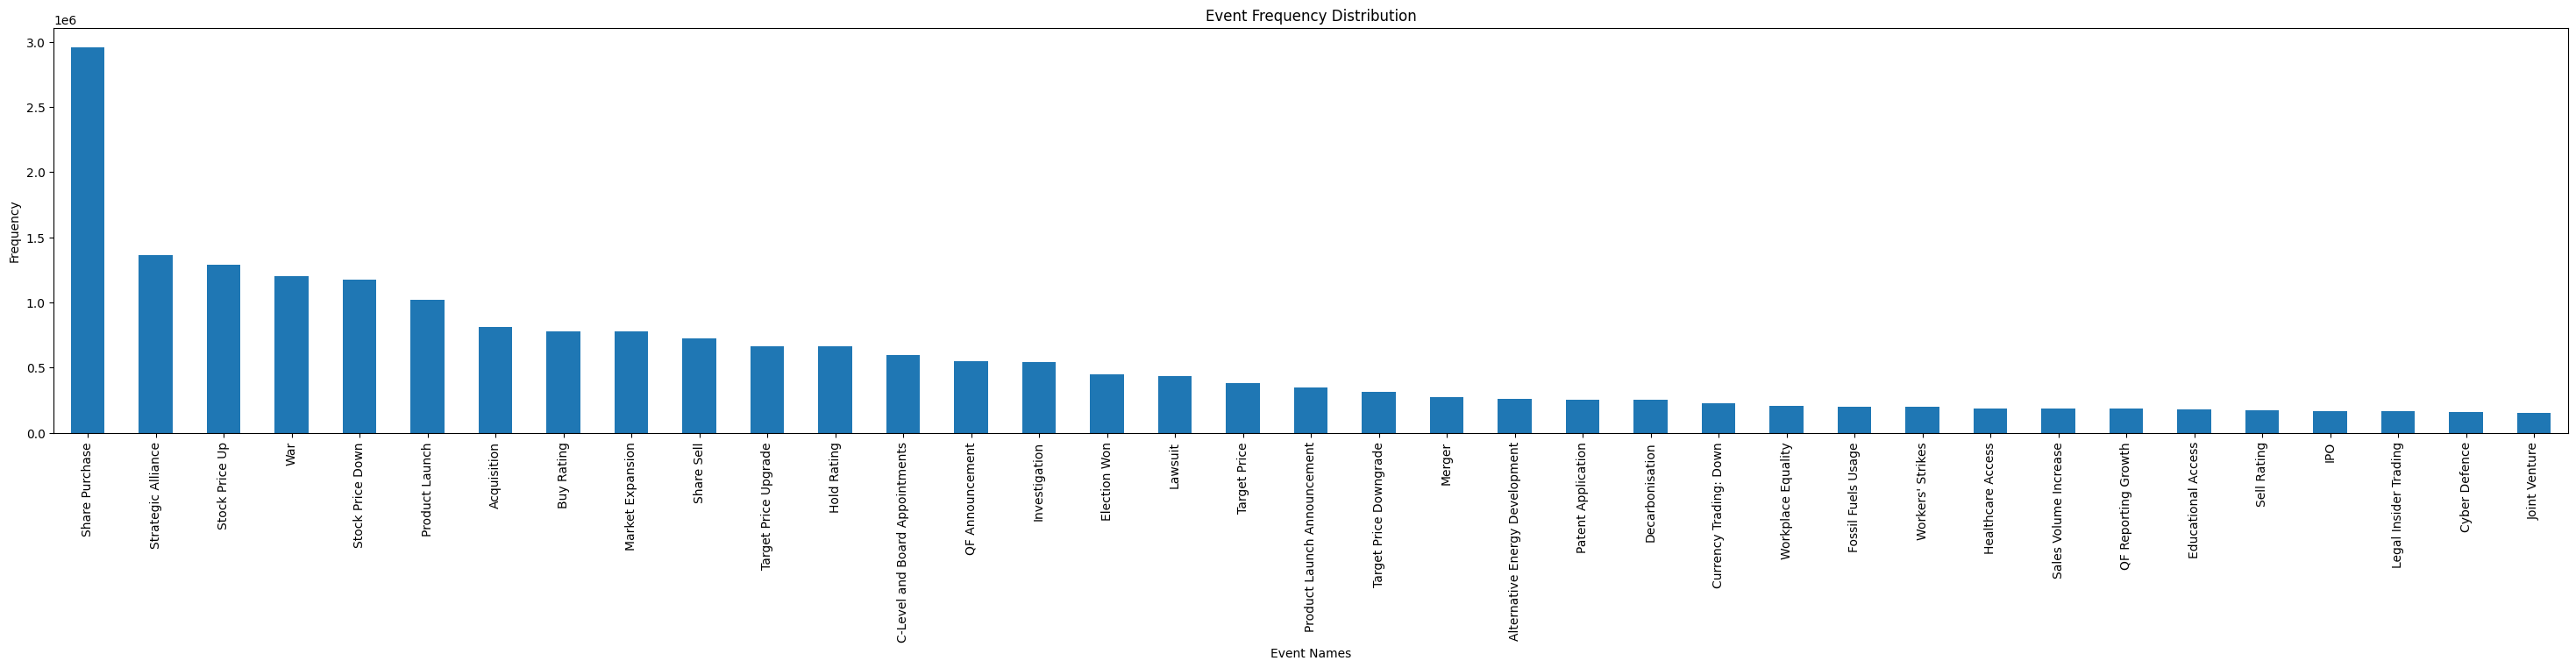

In [14]:
events_freq = event_data['event_name'].value_counts()
# since there are too many events, select only 1st percentile (around 37) shown in this plot 
events_freq_top30 = event_data['event_name'].value_counts()[:37]
plt.figure(figsize=(37, 6))  
bars = events_freq_top30.plot(kind='bar')  
plt.xlabel('Event Names')
plt.ylabel('Frequency')
plt.title('Event Frequency Distribution')

## Table for All Events
Below is the frequency (count) for all the events

In [15]:
table = PrettyTable()
table.field_names = ['Event Name', 'Count']
for event_name, count in events_freq.items():
    table.add_row([event_name, count])
table.align['Count'] = 'r'  # 'r' for right alignment
print(table)

+------------------------------------+---------+
|             Event Name             |   Count |
+------------------------------------+---------+
|           Share Purchase           | 2958789 |
|         Strategic Alliance         | 1366305 |
|           Stock Price Up           | 1289358 |
|                War                 | 1201093 |
|          Stock Price Down          | 1174904 |
|           Product Launch           | 1017471 |
|            Acquisition             |  813697 |
|             Buy Rating             |  780723 |
|          Market Expansion          |  780010 |
|             Share Sell             |  721580 |
|        Target Price Upgrade        |  665681 |
|            Hold Rating             |  664188 |
|   C-Level and Board Appointments   |  596773 |
|          QF Announcement           |  549858 |
|           Investigation            |  545215 |
|            Election Won            |  447669 |
|              Lawsuit               |  436847 |
|            Target 

# Q2 : Distribution of Factuality and Temporality
Vast majority of news have factuality = 0, which is fact.

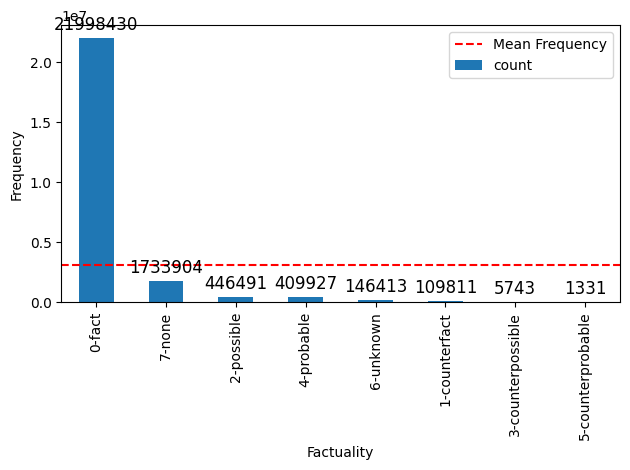

In [16]:
# Factuality
fact_freq= event_data['factuality'].value_counts()
bars = fact_freq.plot(kind = 'bar')
plt.xlabel('Factuality')
plt.ylabel('Frequency')
for bar in bars.containers[0]: 
    height = bar.get_height() 
    plt.annotate(f'{height}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),
                 textcoords='offset points',
                 ha='center', va='bottom', fontsize=12, color='black')
plt.axhline(y=fact_freq.mean(), color='red', linestyle='--', linewidth=1.5, label='Mean Frequency')
plt.legend()
plt.tight_layout()

Most of news have temporality = 0, which is past. The second highest amounts is temporality = 1 that represents present.

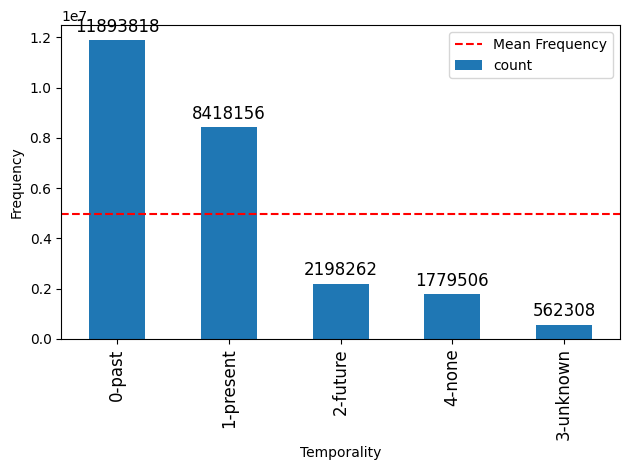

In [17]:
# Temporality
temp_freq = event_data['temporality'].value_counts()
bars = temp_freq.plot(kind='bar')
plt.xlabel('Temporality')
plt.xticks(rotation=90, ha='center', fontsize=12)
plt.ylabel('Frequency')
for bar in bars.containers[0]:
    height = bar.get_height() 
    plt.annotate(f'{height}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),
                 textcoords='offset points',
                 ha='center', va='bottom', fontsize=12, color='black')
plt.axhline(y=temp_freq.mean(), color='red', linestyle='--', linewidth=1.5, label='Mean Frequency')
plt.legend()
plt.tight_layout()
plt.show()

# Q3 : Detected Participant

### How many events have NO detected participant?
15.4 % of news do not have detected participant

In [19]:
event_data['event_participant_id'].isna().sum()
event_data['event_participant_id'].isna().sum() / len(event_data['event_participant_id'])

0.15400411636062217

### Participant Rate for Each Event

#### This cell computes the percentage from 0 to 1, of how often an event has a participant assgned to it.
Highest Participant Rate = Participant are most likely detected in news contain this event 
<br> 1. Share Purchase
<br> 2. Product Launch Announcement
<br> 3. War

Lowest Participant Rate = Participant are NOT likely detected in news contain this event 
<br> 1. Healthcare Access
<br> 2. Short Bets Decrease
<br> 3. Biodiversity Loss


In [21]:
participant_rate = {}
n = len(event_data['event_name'].unique().tolist())
for i in range(n):
    id = event_data['event_name'].unique().tolist()[i] # name (type string)
    event_subset = event_data[event_data['event_name'] == id] # subset df for that event
    participant_rate[id, i] = event_subset['event_participant_id'].notna().sum() / len(event_subset['event_participant_id']) # NOT missing

#participant_rate

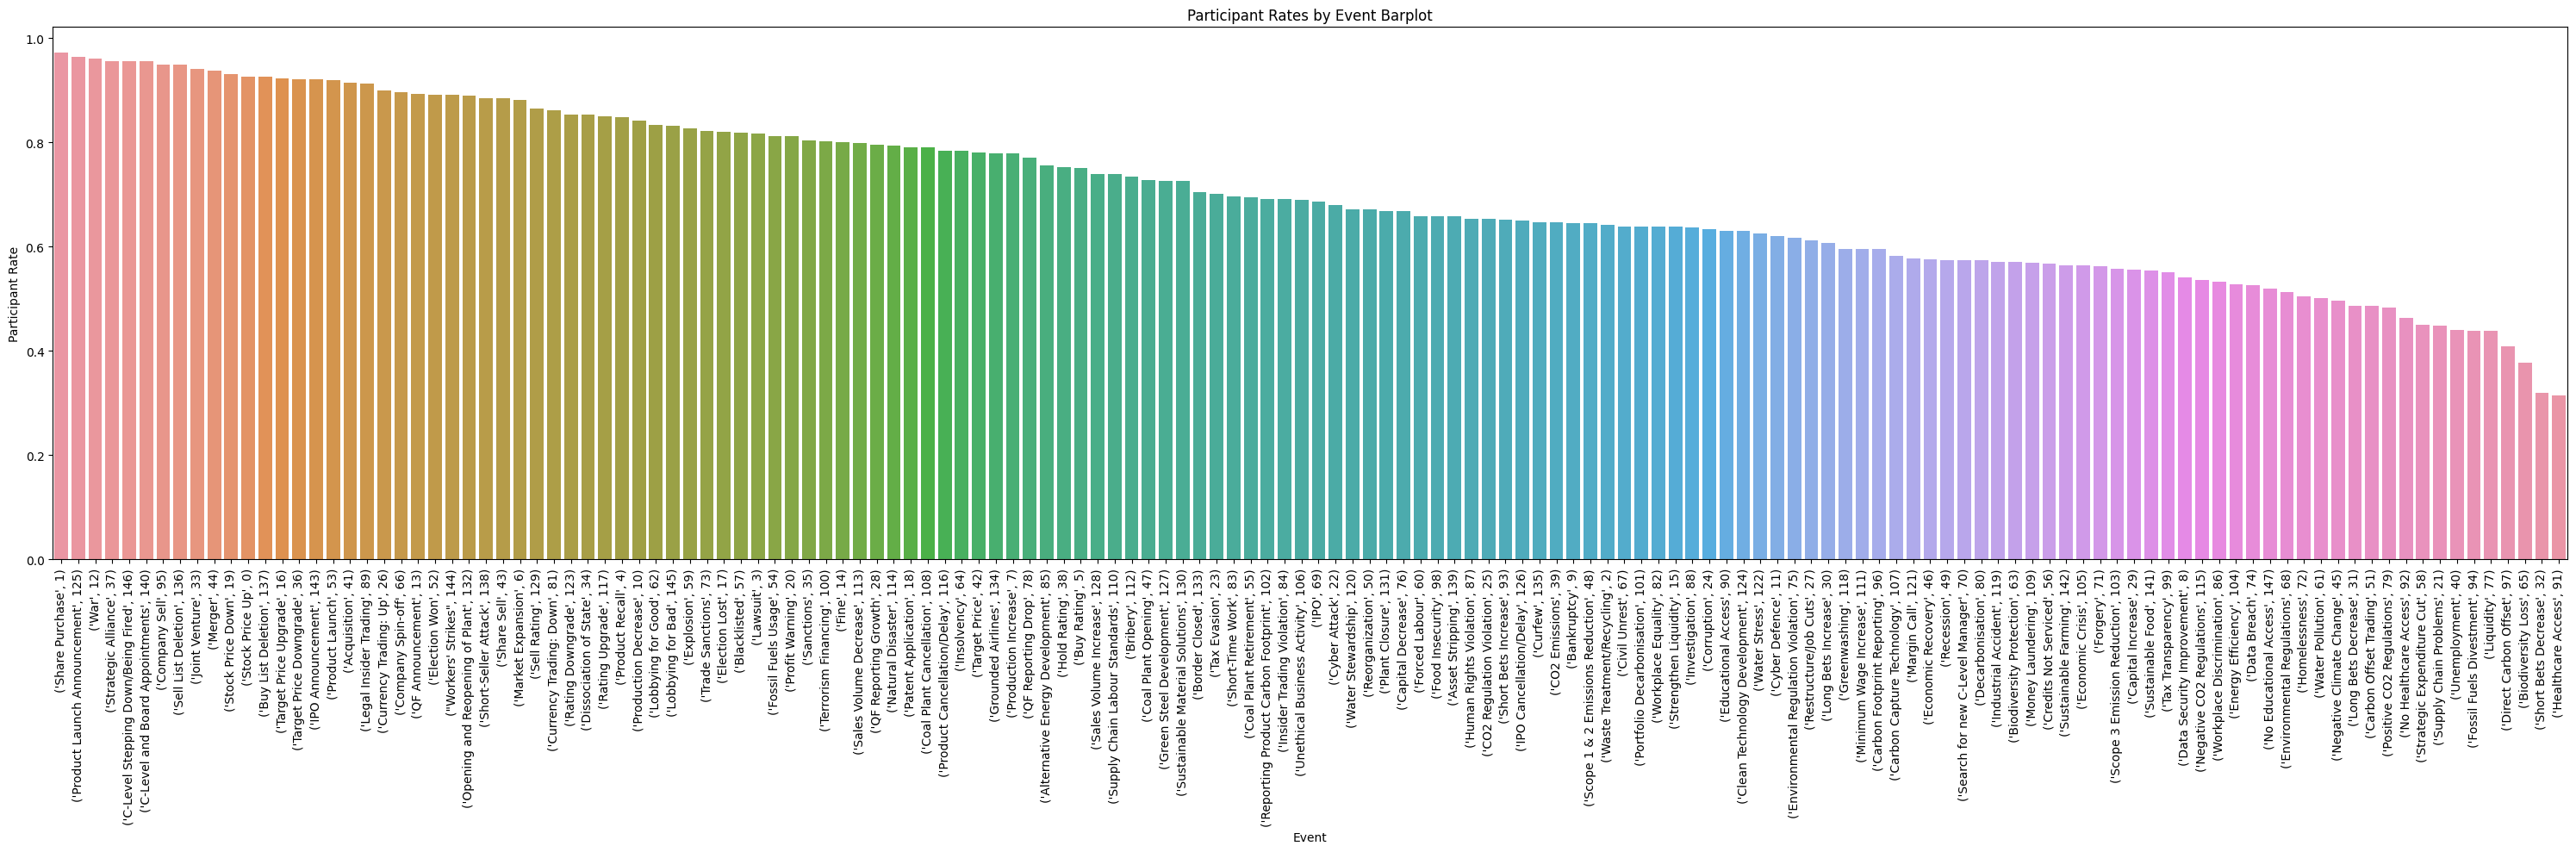

In [35]:
participant_rate_list = [(event, rate) for event, rate in participant_rate.items()]
participant_rate_df = pd.DataFrame(participant_rate_list, columns=['Event', 'Participant Rate'])
participant_rate_df = participant_rate_df.sort_values(by='Participant Rate', ascending=False)

plt.figure(figsize=(30, 10))
sns.barplot(x='Event', y='Participant Rate', data=participant_rate_df)
plt.xticks(rotation=90)
plt.title('Participant Rates by Event Barplot')
plt.xlabel('Event')
plt.ylabel('Participant Rate')
plt.tight_layout()
plt.savefig('Participant Rates by Event Barplot.png')
plt.show()
plt.close()


In [23]:
# A data frame with same information but more specific values
participant_rate_df

,Event,Participant Rate
1,"(Share Purchase, 1)",0.972419
125,"(Product Launch Announcement, 125)",0.963308
12,"(War, 12)",0.960771
37,"(Strategic Alliance, 37)",0.955454
146,"(C-Level Stepping Down/Being Fired, 146)",0.954905
...,...,...
77,"(Liquidity, 77)",0.438046
97,"(Direct Carbon Offset, 97)",0.408478
65,"(Biodiversity Loss, 65)",0.377288
32,"(Short Bets Decrease, 32)",0.319018


# Q4 : Distribution of Language
English news dominated

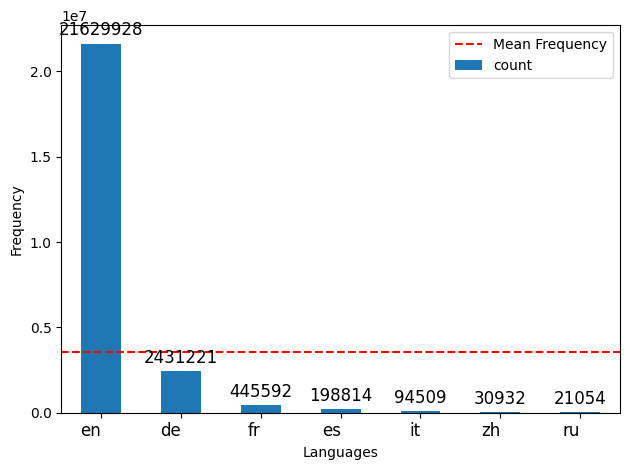

In [24]:
lang_freq = event_data['news_lang'].value_counts()
bars = lang_freq.plot(kind='bar')
plt.xlabel('Languages')
plt.ylabel('Frequency')
plt.xticks(rotation=0, ha='right', fontsize=12)
for bar in bars.containers[0]: 
    height = bar.get_height() 
    plt.annotate(f'{height}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),
                 textcoords='offset points',
                 ha='center', va='bottom', fontsize=12, color='black')
plt.axhline(y=lang_freq.mean(), color='red', linestyle='--', linewidth=1.5, label='Mean Frequency')
plt.legend()
plt.tight_layout()

# Q5 : Correlations Between Events

This cell converts timestamp (unix epoch time) column into date time format

In [25]:
# the dataformat defines how granular this should be: '%Y-%m-%d %H' for hourly, '%Y-%m-%d %H:%M' for minutes, '%Y-%m-%d' for days
# we use days
event_data['date_stamp'] = event_data['timestamp'].apply(lambda x: datetime.datetime.fromtimestamp(x).strftime('%Y-%m-%d %H'))
#print(event_data['timestamp'].head())

Correlation are calculated based on timestamp values

In [26]:
timeseries_data = {}
for id in event_data['event_name'].unique().tolist():
    data_tmp = event_data[event_data['event_name'] == id]
    timeseries = data_tmp[['date_stamp', 'event_name']].groupby('date_stamp').count()
    timeseries_data[id] = timeseries

Correlation values for all pairs of events

In [27]:
correlation = {}
for i in event_data['event_name'].unique().tolist():
    for j in event_data['event_name'].unique().tolist():
        if i != j:  
            timeseries_i = timeseries_data[i]['event_name'].tolist()
            timeseries_j = timeseries_data[j]['event_name'].tolist()
            if len(timeseries_i) == len(timeseries_j):
                corr_matrix = np.corrcoef(timeseries_i, timeseries_j)
                correlation[(i, j)] = corr_matrix[0, 1]
                print(f'Correlation (1) {i} (2) {j}: {corr_matrix[0, 1]}')

Correlation (1) Stock Price Up (2) Share Purchase: 0.525690870008036
Correlation (1) Stock Price Up (2) Lawsuit: 0.4975145802512364
Correlation (1) Stock Price Up (2) Buy Rating: 0.6259594536727189
Correlation (1) Stock Price Up (2) Market Expansion: 0.7306899761747847
Correlation (1) Stock Price Up (2) Production Increase: 0.5706980412892161
Correlation (1) Stock Price Up (2) Data Security Improvement: 0.56761467964916
Correlation (1) Stock Price Up (2) Bankruptcy: 0.29483173591317136
Correlation (1) Stock Price Up (2) Cyber Defence: 0.5846701347836248
Correlation (1) Stock Price Up (2) War: 0.44788596768943595
Correlation (1) Stock Price Up (2) QF Announcement: 0.5006244333560201
Correlation (1) Stock Price Up (2) Fine: 0.4478124828639057
Correlation (1) Stock Price Up (2) Target Price Upgrade: 0.538934842281381
Correlation (1) Stock Price Up (2) Election Lost: 0.20744135605160535
Correlation (1) Stock Price Up (2) Stock Price Down: 0.8877987732470756
Correlation (1) Stock Price Up (

## Plots and Explore for Significant Correlations

### Distribution of Correlations
This plot shows how the frequency of correlation values. 
<br> The distribution of correlation follows a normal distribution and skews to right, which means there are more correlations between events that are clustered around the lower end of the spectrum (below 0.2). 
<br> Red lines are percentiles

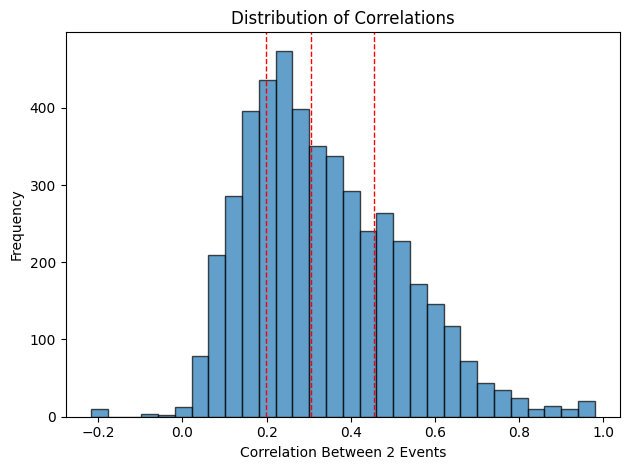

In [28]:
correlation_val = list(correlation.values())
correlation_val.sort(reverse=True)

percentiles = [25, 50, 75]
percentile_values = np.percentile(correlation_val, percentiles)

for percentile in percentile_values:
    plt.axvline(percentile, color='r', linestyle='dashed', linewidth=1)

plt.hist(correlation_val, bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribution of Correlations')
plt.xlabel('Correlation Between 2 Events')
plt.ylabel('Frequency')
plt.tight_layout()

### Exploration on Correlations Above threshold >= 0.5
Let's set the threshould = 0.5 and explore events that have correlations higher than this threshould.

In [29]:
threshold = 0.5

In [30]:
corr_big = []
for pair, value in correlation.items():
    if value >= threshold:
        corr_big.append((pair, value))

In [31]:
corr_big_df = pd.DataFrame(corr_big, columns=['Pairs', 'Correlation'])
corr_big_df = corr_big_df.sort_values(by='Correlation', ascending=False)
corr_big_df[['Event1', 'Event2']] = pd.DataFrame(corr_big_df['Pairs'].tolist(), index=corr_big_df.index) # split Pairs into Events
#corr_big_df

In [32]:
pivot_table = corr_big_df.pivot(index='Event1', columns='Event2', values='Correlation')
#pivot_table

### Heatmap for Events with Correlation >= 0.5

#### Correlations above 0.90 (darkest red) for Any 2 of these events
<br> - Hold rating
<br> - Target price
<br> - Target price upgrade
<br> - Buy rating
<br> - Share sell
<br> - Share purchase


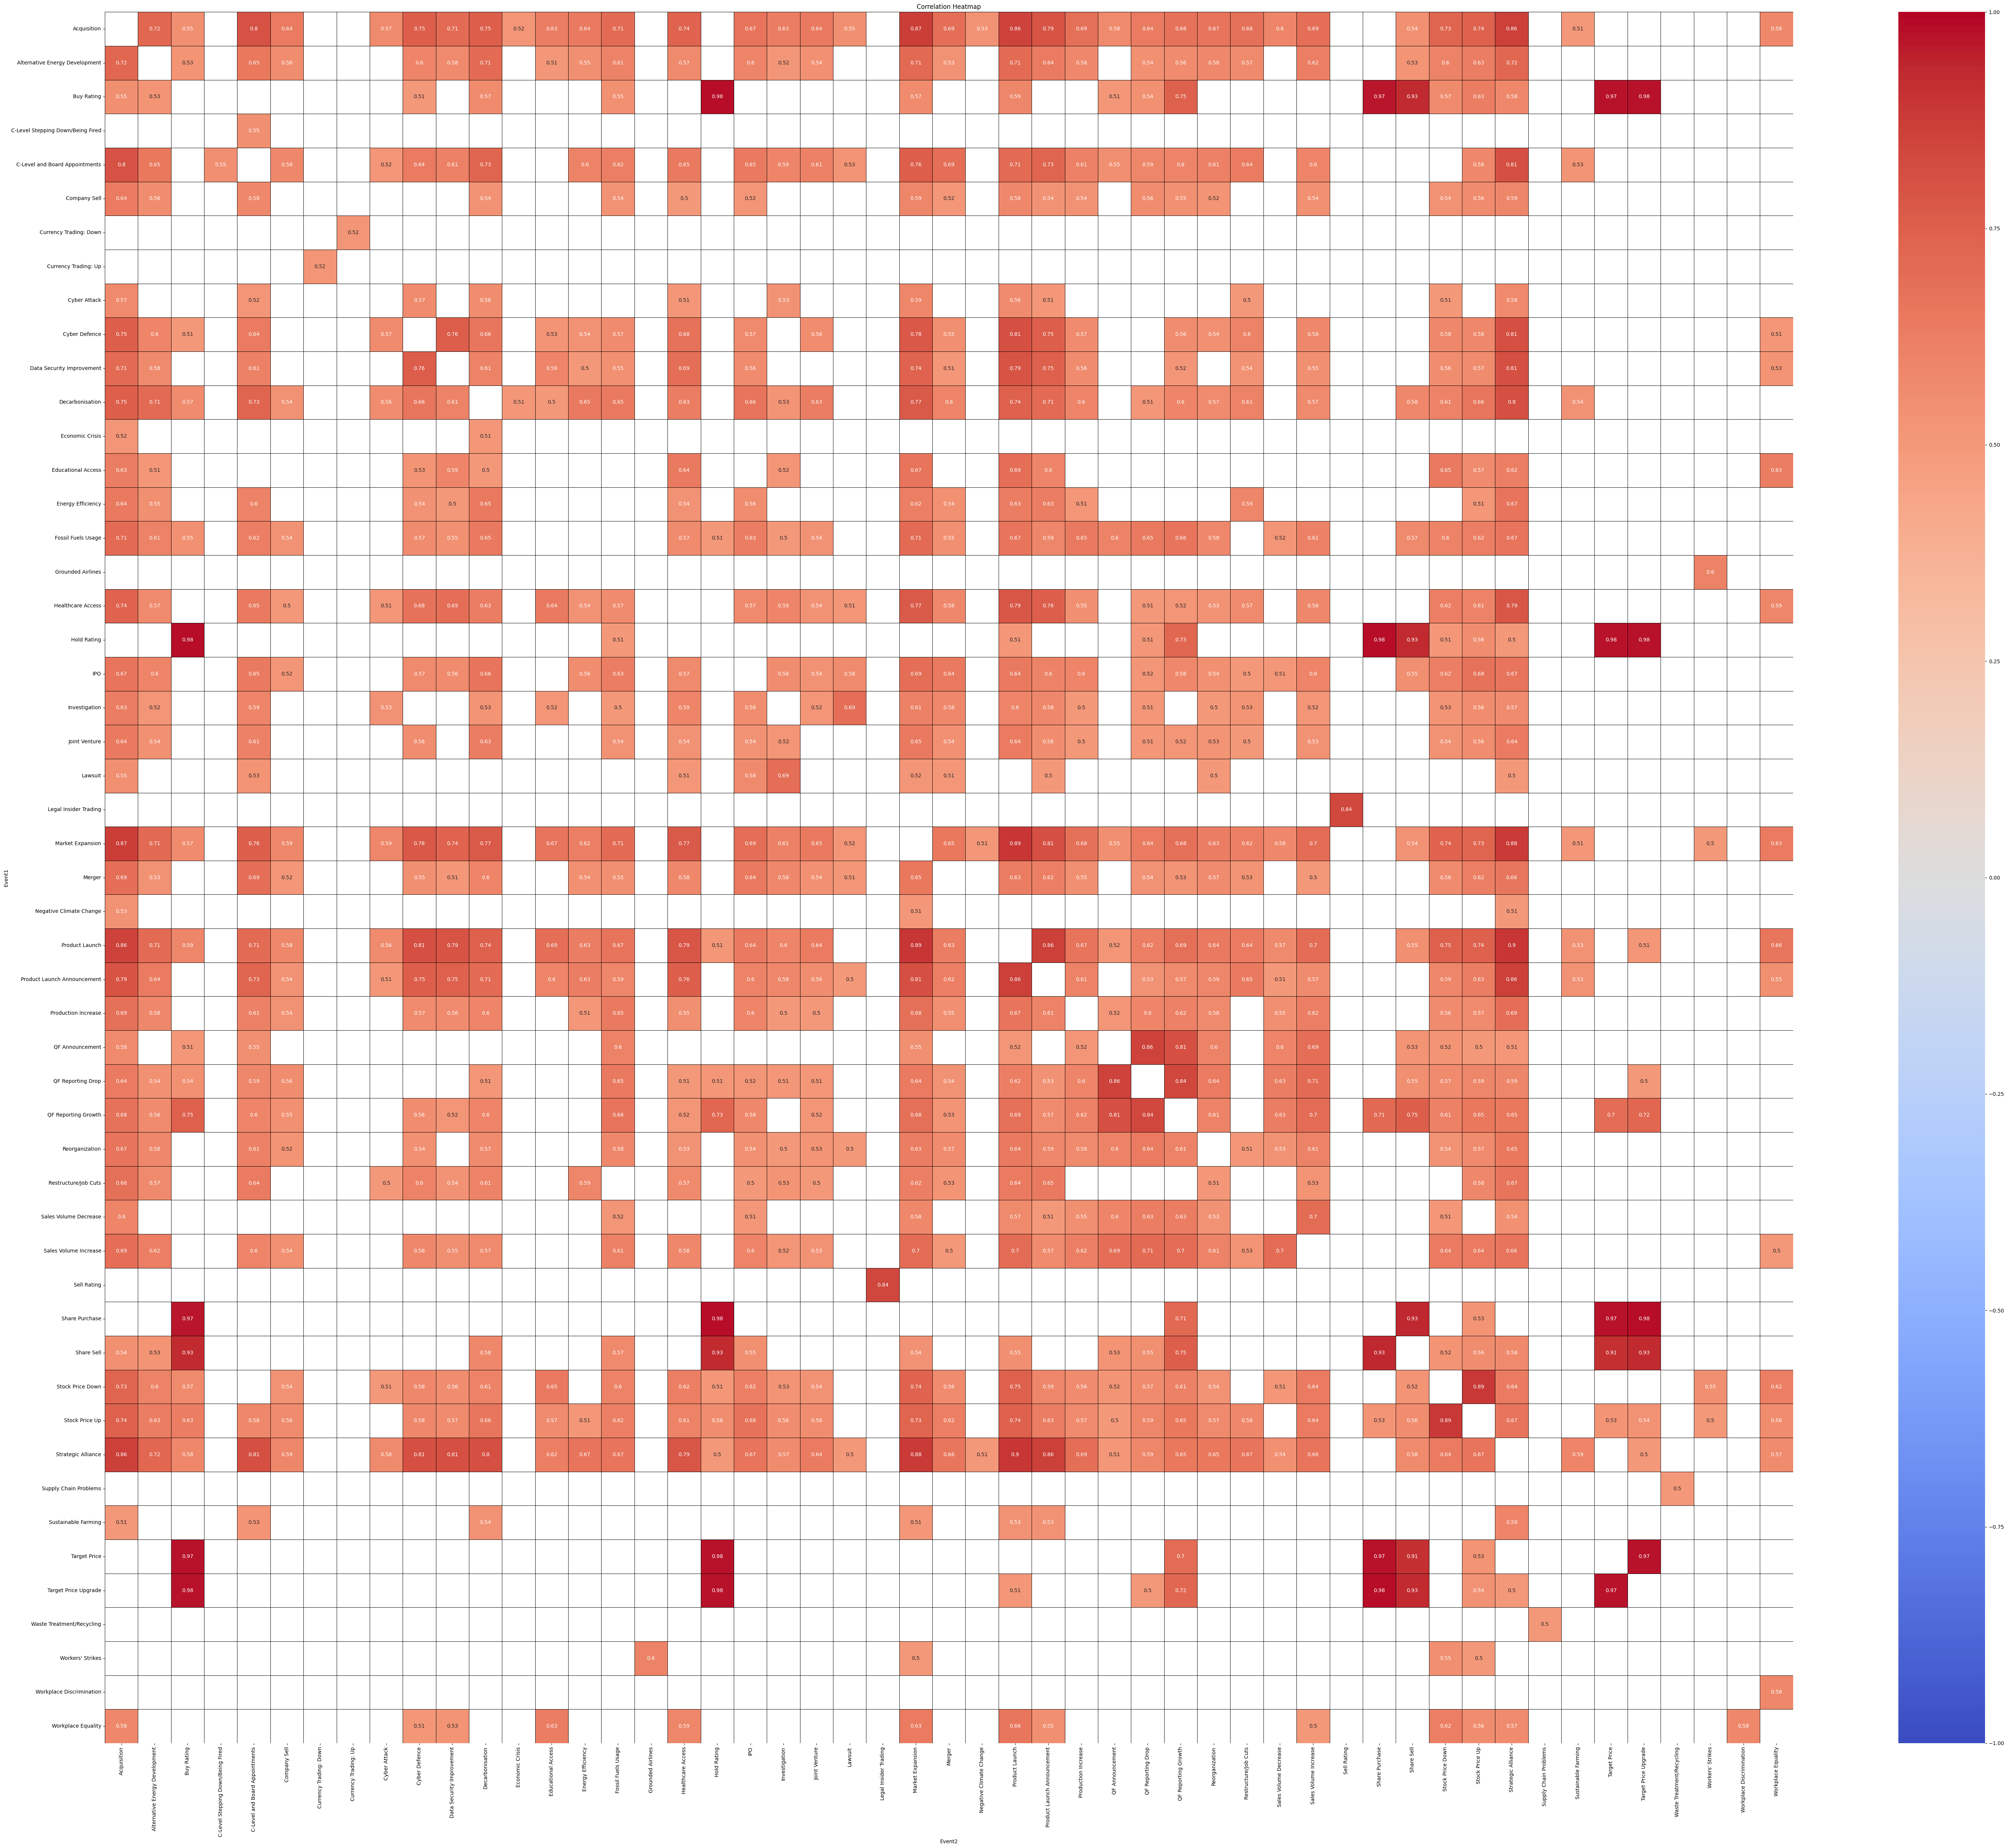

In [33]:
plt.figure(figsize=(60, 50))
sns.heatmap(pivot_table, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, linecolor='black')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation.png') # save before show! otherwise saved is empty
plt.show()
plt.close()

### Network Diagram for Events with Correlations >= 0.5 (Edge weighted based on Correlation Values)
So we can see what events are forming clusters

/var/folders/tp/6kwhdvr504795tj0h4_byy2c0000gn/T/ipykernel_70106/320720943.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


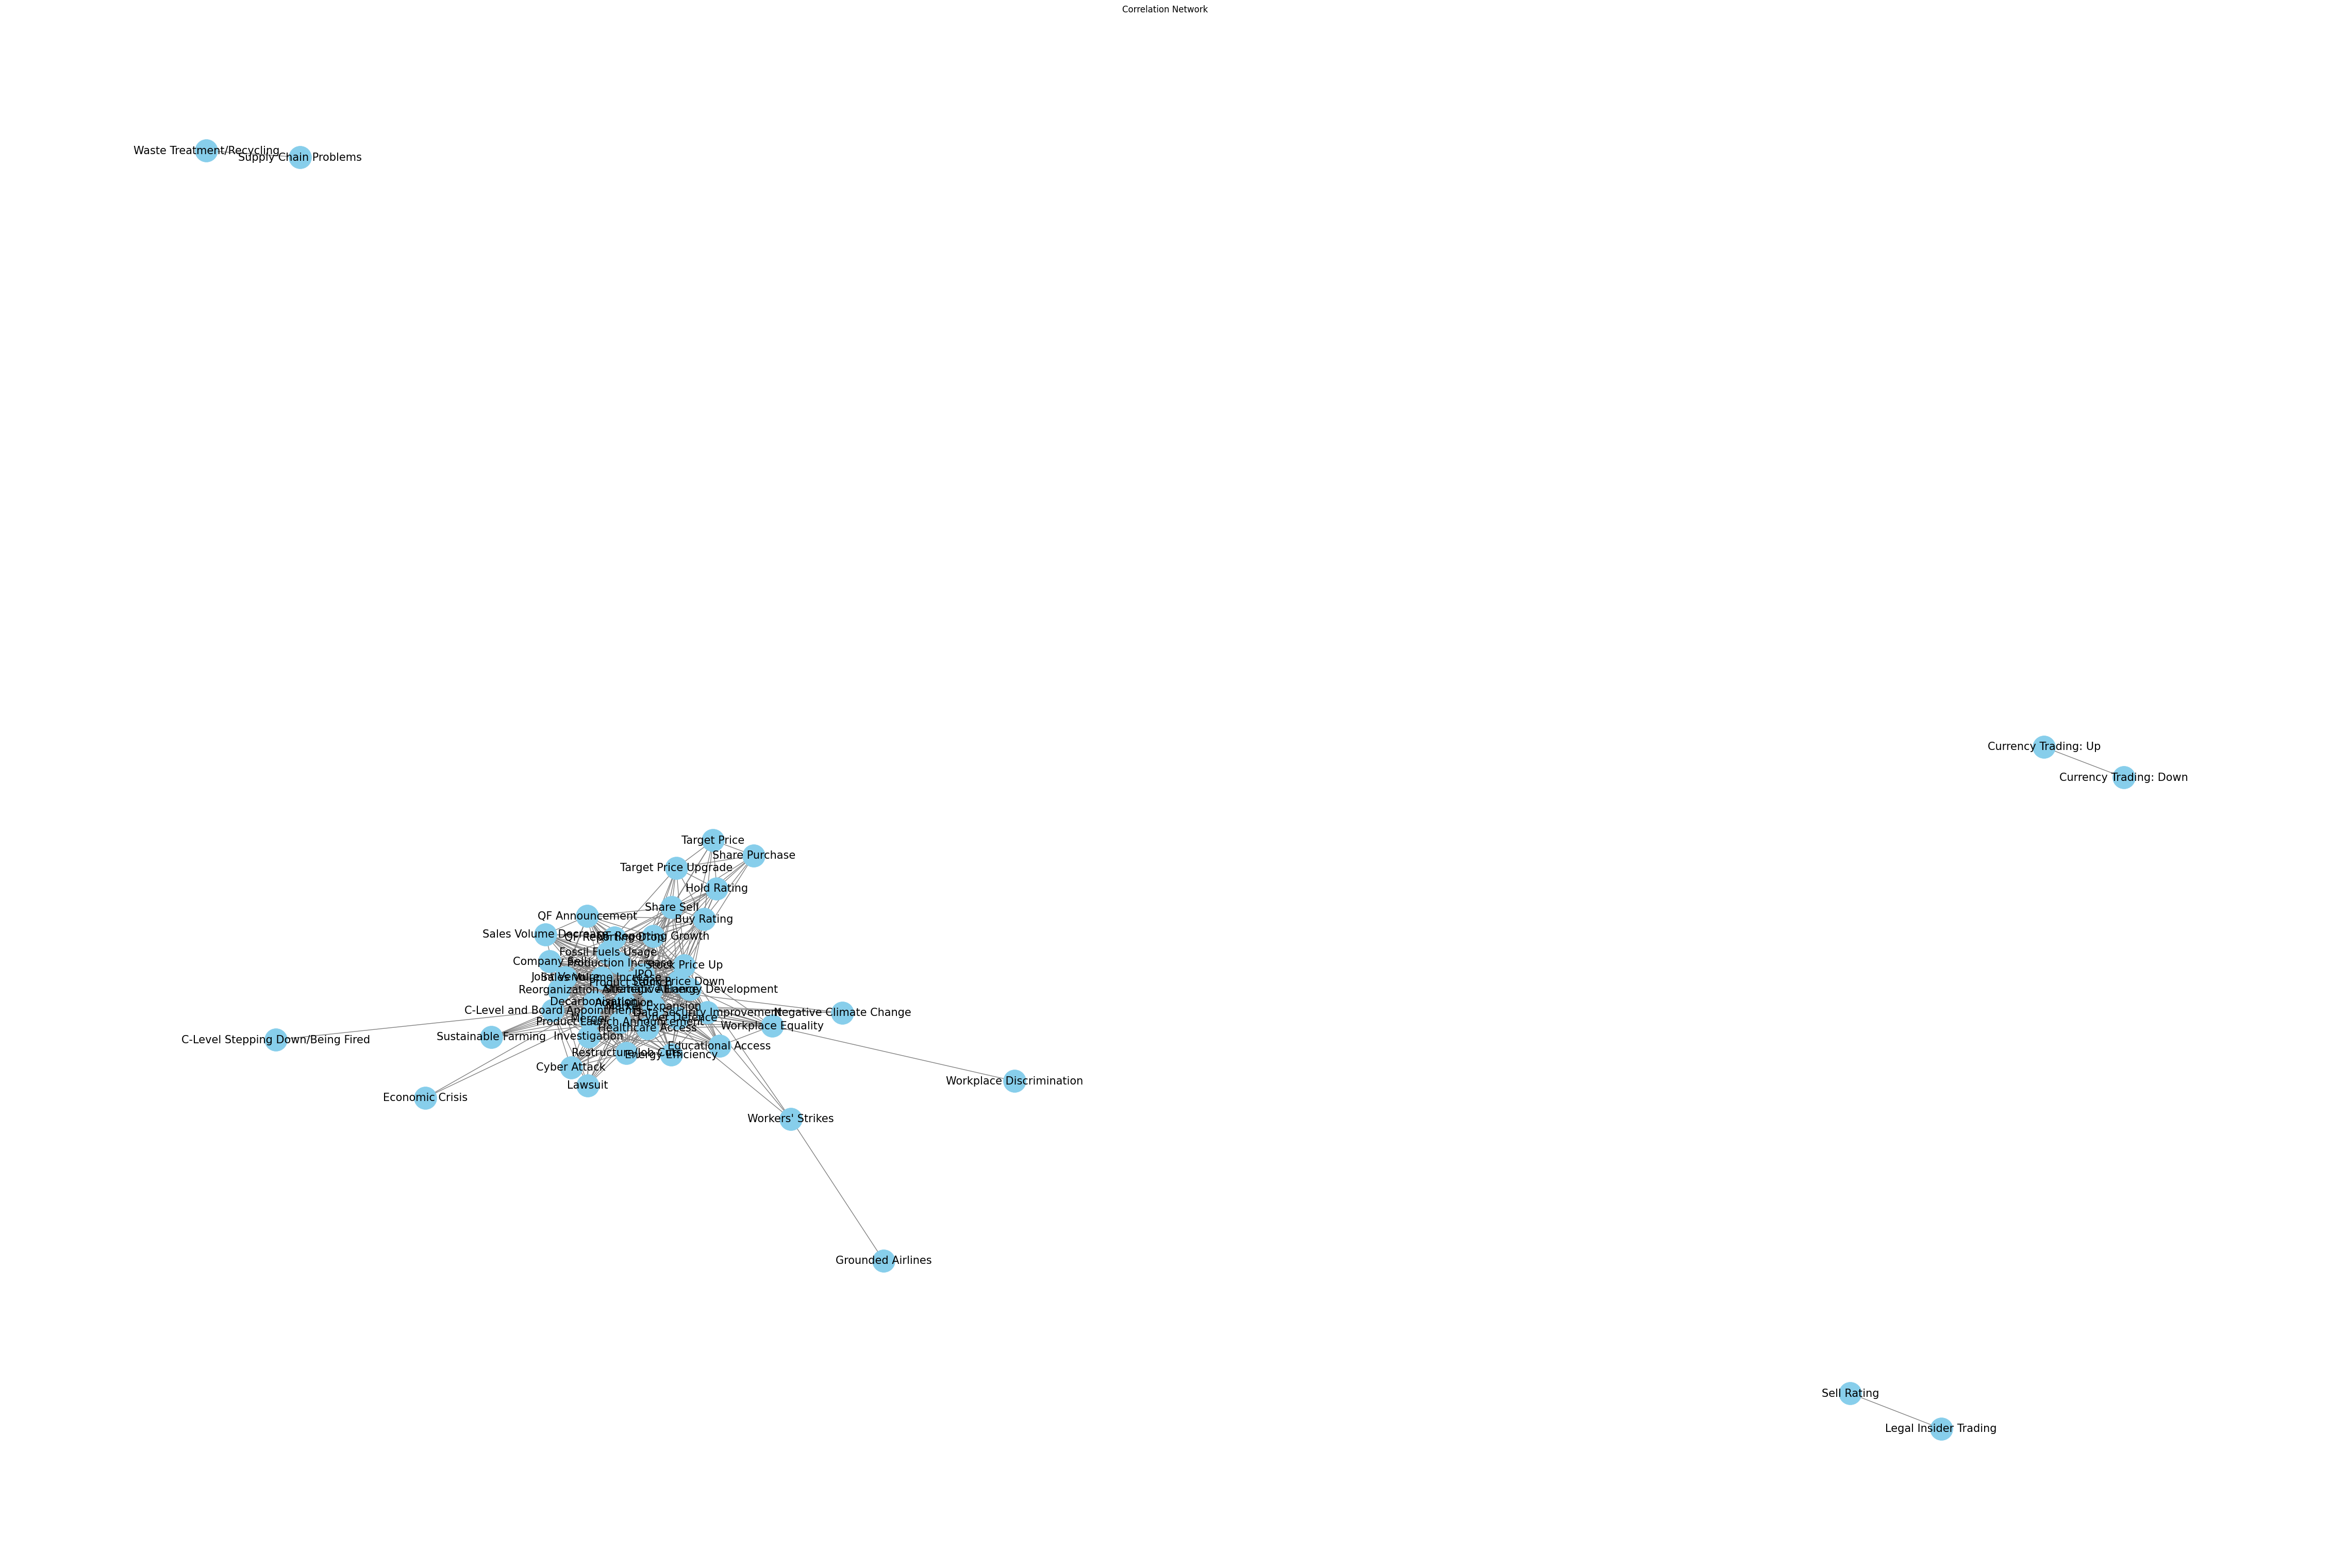

In [34]:
import networkx as nx

G = nx.Graph()
for (event1, event2), correlation_val in corr_big: # corr_big only contains corr >= 0.5 
    G.add_edge(event1, event2, weight=correlation_val)

plt.figure(figsize=(45, 30))
pos = nx.spring_layout(G, seed=42)  
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=1000, font_size=15, edge_color='gray', linewidths=0.5)
plt.title('Correlation Network')
plt.tight_layout()
plt.savefig('network.png') # save before show! otherwise saved is empty
plt.show()
plt.close()